### Reduced Order Model (ROM) builder for Direct Firing Furnace (DFF) configuration

**IMPORTANT**: before running this notebook, you **MUST** collect the data and placing them in the right folder. \

*NB*: it is recommended to create a virtual environment -->
- open terminal and then in the shell: \
```$ python -m venv name-of-the-environment``` --> activate environment -->
   - if working with *MacOS/Linux*: ```$ source name-of-the-environment/bin/activate```;
   - if working with *Windows*: ```$ name-of-the-environment/Scripts/activate```
- then install the kernel needed for running the notebook via: ```$ python(or py) pip install ipykernel```
- open this notebook and manually select the kernel pointing to the environment selected.

*NB2*: all of training options can be selected by looking at the ```config.json``` file.

*Alternatively in the ```SRC``` folder there is a file named ```train.py``` to does the exact same thing as this one, if the notebook doesn't run.*

***Downloading libraries:*** \
Download libraries needed to perform the computation of the POD and the training of the model (optional, if already present you can check doing ```$ pip list``` and skip the following cell)

In [ ]:
import subprocess
import sys

packages = ["torch", "gpytorch", "numpy", "pandas", "matplotlib", "scipy", "cvxpy", "pyvista"]

pipList = subprocess.run([sys.executable, "-m", "pip", "list"], capture_output=True, text=True)
pipList = pipList.stdout.lower()

for package in packages:
    if package not in pipList:   # checks if the package is already installed
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])

***Importing libraries:*** \
Import custom libraries containing all needed functions, if needed you can check what each function does by reading the comments added at the top of their definition. \
(a log file will also be created to check whether the training is successful)

In [ ]:
from SRC.gpr import *
from SRC.utils import *

# for printing model outputs
name_logfile = os.path.join(os.getcwd(), 'log-gpr.txt')
open(name_logfile, "w").close()   # in case there is already one
log = open(name_logfile, "a")

***Loading data:*** \
Two sets of data must be loaded:
1. table containing a list of the conditions we wish to explore in format (p, d) \
where **p** is the number of operating conditions and **d** is the number of design parameters;
2. table containing a list of all the simulation data in format (n_cells, n_vars).

In [ ]:
print('============================', file=log, flush=True)
print('STARTING GPR TRAINING', file=log, flush=True)
print('============================', file=log, flush=True)

path = os.path.join(os.getcwd(), 'DATA')

# setting parameters for training
paramDict = {
    'data_folder': None,
    'normalization': {
        'scaleP_type': 'std',
        'scaleX_type': 'std',
        'axis_cnt': 1
    },

    'POD': {
        'select_modes': 'variance',
        'n_modes': 99
    },
    
    'GPR_training': {
        'idx_test': [5, 15, 23],
        'max_iter': 1000,
        'rel_error': 1e-05,
        'lr': 0.1
    }
}
read_param(paramDict, os.path.join(path, '../config.json'))
data_folder = paramDict['data_folder']
print('- Loading data from: {}'.format(data_folder), file=log, flush=True)

# opening cases
print('- Reading design space...', file=log, flush=True)
dfP = pd.read_csv(os.path.join(path, 'cases_parameters.csv'), sep=" ")
n_p = dfP.shape[0]   # number of cases
d = dfP.columns.to_list()
n_d = len(d)    # number of design parameters
print('  * Using design parameters -> {}'.format(d), file=log, flush=True)
print(' !!! DONE !!! -> {}\n'.format(dfP.shape), file=log, flush=True)

# opening simulations
print('- Reading simulation cases (strip temperature)...', file=log, flush=True)
X, features, n_cells = read_simulation(path, data_folder, log=log)
n_features = len(features)
X = X.T   # to match dimensions
print(' !!! DONE !!! -> data shape: {} feature(s): {}\n'.format(X.shape, features), file=log, flush=True)

print('- Reading simulation cases (chimney temperature & species)...', file=log, flush=True)
X_species, features_species, n_cells_species = read_simulation(path, os.path.join(data_folder, 'chimney_species'), log=log, species=True)
X_species = X_species.T
n_features_species = len(features_species)
print(' !!! DONE !!! -> data shape: {} feature(s): {}\n'.format(X_species.shape, features_species), file=log, flush=True)

print('- Reading simulation cases (flame temperature & species)...', file=log, flush=True) # 20260612 D
X_flame, features_flame, n_cells_flame = read_simulation(path, os.path.join(data_folder, 'burners_bot_species'), log=log)
X_flame = X_flame.T
n_features_flame = len(features_flame)
print(' !!! DONE !!! -> data shape: {} feature(s): {}\n'.format(X_flame.shape, features_flame), file=log, flush=True)

***GPR training:*** \
Several operations are performed in this section, starting from the extraction of POD modes to training and testing of the trained GPR model.

The following workflow is what the code does:
```
SIM DATA -> POD MODES EXTRACTION -> GPR TRAINING (input: design space, output: projected sim data in POD space) -> GPR TESTING -> PROJECTING SIM DATA BACK IN PHYSICAL SPACE
```

In [ ]:
print('- Preparing training and testing data...', file=log, flush=True)
idx_test = paramDict['GPR_training']['idx_test']
print('- Using sim case(s): {} to test'.format(idx_test), file=log, flush=True)

P = dfP.to_numpy()
P_train = np.delete(P, idx_test, axis=0)
P_test = P[idx_test]

X_train = np.delete(X, idx_test, axis=1)
X_test = X[:, idx_test]

X_species_train = np.delete(X_species, idx_test, axis=1)
X_species_test = X_species[:, idx_test]

X_flame_train = np.delete(X_flame, idx_test, axis=1)
X_flame_test = X_flame[:, idx_test]

In [ ]:
# create GPR object and train
print('- Training of GPR model...', file=log, flush=True)
gpr = GPR(X_train, X_species_train, X_flame_train, n_features, n_features_species, n_features_flame, P_train)

gpr.fit(scaleP_type=paramDict['normalization']['scaleP_type'], 
        scaleX_type=paramDict['normalization']['scaleX_type'], 
        axis_cnt=paramDict['normalization']['axis_cnt'],
        select_modes=paramDict['POD']['select_modes'], 
        n_modes=paramDict['POD']['n_modes'])

models, likelihoods = gpr.train(kernel=gpytorch.kernels.ScaleKernel(gpytorch.kernels.LinearKernel(ard_num_dims=gpr.P.shape[1]) + 
                                                                    gpytorch.kernels.MaternKernel(nu=2.5, ard_num_dims=gpr.P.shape[1])),
                                max_iter=paramDict['GPR_training']['max_iter'], 
                                rel_error=paramDict['GPR_training']['rel_error'],
                                lr=paramDict['GPR_training']['lr'],
                                verbose=bool(paramDict['GPR_training']['verbose']), log=log)

gpr.save(os.path.join(path, 'trained_gpr.pth'))

In [7]:
# print(models)
# print(likelihoods)
print(' \n', file=log, flush=True)
print('- Data shape: X_train{} X_species_train{} X_flame_train{} P_train{} n_features{} n_features_species{} n_features_flame{}'
      .format(X_train.shape, X_species_train.shape, X_flame_train.shape, P_train.shape, n_features, n_features_species, n_features_flame), file=log, flush=True)
print('- Data shape: X_test{} X_species_test{} X_flame_test{} P_test{}'
      .format(X_test.shape, X_species_test.shape, X_flame_test.shape, P_test.shape), file=log, flush=True)
print('- Data shape: Ur{} Ar{} self.P{} Ur_species{} Ar_species{} Ur_flame{} Ar_flame{} \n'
      .format(gpr.Ur.shape, gpr.Ar.shape, gpr.P.shape, gpr.Ur_species.shape, gpr.Ar_species.shape, gpr.Ur_flame.shape, gpr.Ar_flame.shape), file=log, flush=True)

***Training results visualization:***\
Contour plots of temperature are shown relative to the cases used for training.

In [8]:
# visualize results
Ap, sigmaP = gpr.predict(P_train) # Ap: POD coefficient, SigmaP: uncertainty (standard deviation) over POD coefficient

Xp0 = gpr.reconstruct(Ap[:, :gpr.r], modes=gpr.Ur)   # reconstruct only the dimension where POD coefficients are stored
SigmaX0 = gpr.reconstruct(sigmaP[:, :gpr.r], modes=gpr.Ur) # standard deviation

# extract results for chimney species
# Xp_species = Ap[:,gpr.r:].copy()
# sigmaX_species = sigmaP[:, gpr.r:].copy()
Xp0_species = gpr.reconstruct(Ap[:, gpr.r:gpr.r+gpr.r_species], modes=gpr.Ur_species)   # reconstruct only the dimension where POD coefficients are stored
SigmaX0_species = gpr.reconstruct(sigmaP[:, gpr.r:gpr.r+gpr.r_species], modes=gpr.Ur_species) # standard deviation

# extract results for flame species # 20260612 D
Xp0_flame = gpr.reconstruct(Ap[:, gpr.r+gpr.r_species:gpr.r_t], modes=gpr.Ur_flame)   # reconstruct only the dimension where POD coefficients are stored
SigmaX0_flame = gpr.reconstruct(sigmaP[:, gpr.r+gpr.r_species:gpr.r_t], modes=gpr.Ur_flame) # standard deviation

print('- Data shape: Ap{} sigmaP{} Xp0{} SigmaX0{} Xp0_species{} SigmaX0_species{} Xp0_flame{} SigmaX0_flame{} gpr.r{} gpr.r_species{} gpr.r_flame{} gpr.r_t{}'
      .format(Ap.shape, sigmaP.shape, Xp0.shape, SigmaX0.shape, Xp0_species.shape, SigmaX0_species.shape, 
              Xp0_flame.shape, SigmaX0_flame.shape, gpr.r, gpr.r_species, gpr.r_flame, gpr.r_t), file=log, flush=True)
print('- Data shape: gpr.X_cnt{} gpr.X_cnt_species{} gpr.X_cnt_flame{} \n'.format(gpr.X_cnt.shape, gpr.X_cnt_species.shape, gpr.X_cnt_flame.shape), file=log, flush=True)

/opt/homebrew/lib/python3.11/site-packages/gpytorch/models/exact_gp.py:299: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(


In [9]:
# denorm strip outlet temperature data
Xp = np.empty_like(Xp0)
SigmaX = np.empty_like(SigmaX0)

# denorm uncertainty
SigmaX = SigmaX0 * gpr.X_scl

# denorm prediction
for j in range(n_features):
    cnt = gpr.X_cnt[j,:] if paramDict['normalization']['axis_cnt'] == 0 else gpr.X_cnt[j*n_cells:(j+1)*n_cells,:]
    Xp[j*n_cells:(j+1)*n_cells,:] = (Xp0[j*n_cells:(j+1)*n_cells,:] * gpr.X_scl[j*n_cells:(j+1)*n_cells]) + cnt

In [10]:
# denorm chimney species data
Xp_species = np.empty_like(Xp0_species)
Xp_species_mean = np.empty((X_species_train.shape[1], n_features_species))
X_species_train_mean = np.empty((X_species_train.shape[1], n_features_species))
sigmaX_species = np.empty_like(SigmaX0_species)
sigmaX_species_mean = np.empty_like(Xp_species_mean)

# denorm uncertainty
sigmaX_species = SigmaX0_species * gpr.X_scl_species

# denorm prediction
for j in range(n_features_species):    
    cnt = gpr.X_cnt_species[j,:] if paramDict['normalization']['axis_cnt'] == 0 else gpr.X_cnt_species[j*n_cells_species:(j+1)*n_cells_species,:]
    Xp_species[j*n_cells_species:(j+1)*n_cells_species,:] = (Xp0_species[j*n_cells_species:(j+1)*n_cells_species,:] * gpr.X_scl_species[j*n_cells_species:(j+1)*n_cells_species]) + cnt
    # building mean tensors
    for i in range(X_species_train.shape[1]):
        Xp_species_mean[i, j] = Xp_species[j*n_cells_species:(j+1)*n_cells_species,i].mean(axis=0).item()
        X_species_train_mean[i, j] = X_species_train[j*n_cells_species:(j+1)*n_cells_species,i].mean(axis=0).item()
        sigmaX_species_mean[i, j] = sigmaX_species[j*n_cells_species:(j+1)*n_cells_species,i].mean(axis=0).item()

# denorm flame temperature & species data # 20260612 D
Xp_flame = np.empty_like(Xp0_flame)
Xp_flame_mean = np.empty((X_flame_train.shape[1], n_features_flame))
X_flame_train_mean = np.empty((X_flame_train.shape[1], n_features_flame))
sigmaX_flame = np.empty_like(SigmaX0_flame)
sigmaX_flame_mean = np.empty_like(Xp_flame_mean)

# denorm uncertainty
sigmaX_flame = SigmaX0_flame * gpr.X_scl_flame

# denorm prediction
for j in range(n_features_flame):    
    cnt = gpr.X_cnt_flame[j,:] if paramDict['normalization']['axis_cnt'] == 0 else gpr.X_cnt_flame[j*n_cells_flame:(j+1)*n_cells_flame,:]
    Xp_flame[j*n_cells_flame:(j+1)*n_cells_flame,:] = (Xp0_flame[j*n_cells_flame:(j+1)*n_cells_flame,:] * gpr.X_scl_flame[j*n_cells_flame:(j+1)*n_cells_flame]) + cnt
    # building mean tensors
    for i in range(X_flame_train.shape[1]):
        Xp_flame_mean[i, j] = Xp_flame[j*n_cells_flame:(j+1)*n_cells_flame,i].mean(axis=0).item()
        X_flame_train_mean[i, j] = X_flame_train[j*n_cells_flame:(j+1)*n_cells_flame,i].mean(axis=0).item()
        sigmaX_flame_mean[i, j] = sigmaX_flame[j*n_cells_flame:(j+1)*n_cells_flame,i].mean(axis=0).item()

In [ ]:
# plot results
avg_T_ref_df = pd.read_csv(os.path.join(path, 'avg_temp.csv'), sep=r"\s+", skipinitialspace=True)

# im_shape_plot = [im_shape[2], im_shape[0]]
feat_idx = 'temperature'   # select the feature to plot
idx = features.index(feat_idx)
idx_train = np.arange(0, n_p, 1)
idx_train = np.delete(idx_train, idx_test, axis=0)

avg_T_ref_df = avg_T_ref_df.iloc[idx_train,:]
avg_T_ref_df = avg_T_ref_df.reset_index()

avg_outlet_T = np.empty((len(idx_train), 4))   # to plot the outlet temperature
coord = pd.read_csv(os.path.join(path, 'plane-xz-strip-middle_outlet', 'case_36cms-5.95MW.csv'), sep=r"\s+", skipinitialspace=True, 
                    usecols=['cellnumber', 'x-coordinate', 'y-coordinate', 'z-coordinate'])   # to save csv in Fluent format
coord_flame = pd.read_csv(os.path.join(path, 'plane-xz-strip-middle_outlet', 'burners_bot_species', 'brbot_case_36cms_5.95MW_speciesT.csv'), sep=r"\s+", skipinitialspace=True, 
                    usecols=['cellnumber', 'x-coordinate', 'y-coordinate', 'z-coordinate'])   # to save csv in Fluent format

# mean evaluation for R2 evaluation
mean = np.empty((n_features,))
mean_species = np.empty((n_features_species,))
mean_flame = np.empty((n_features_flame,))
if paramDict['normalization']['axis_cnt'] == 1:
    for j in range(n_features):
        mean[j] = gpr.X_cnt[j*n_cells:(j+1)*n_cells].mean()
    for j in range(n_features_species):
        mean_species[j] = gpr.X_cnt_species[j*n_cells_species:(j+1)*n_cells_species].mean()
    for j in range(n_features_flame):
        mean_flame[j] = gpr.X_cnt_flame[j*n_cells_flame:(j+1)*n_cells_flame].mean()
else:
    mean = gpr.X_cnt.mean(axis=1)
    mean_species = gpr.X_cnt_species.mean(axis=1)
    mean_flame = gpr.X_cnt_flame.mean(axis=1)

for i in range(len(idx_train)):
    print(' - Plotting results for training case #{} -> {:.2f} MW, strip velocity = {:.2f} m/s'.format(idx_train[i], P_train[i,0], P_train[i,1]))
    print('   i={}, len(idx_train)={}, idx_train(i)={}, idx={}'.format(i, len(idx_train), idx_train[i], idx))
    X_plot = X_train[idx*n_cells:(idx+1)*n_cells, i]
    Xp_plot = Xp[idx*n_cells:(idx+1)*n_cells, i]
    SigmaX_plot = SigmaX[idx*n_cells:(idx+1)*n_cells, i]

    # evaluation of the errors
    Xplot_torch = torch.from_numpy(X_plot)
    XpPlot_torch = torch.from_numpy(Xp_plot)

    norm_error, recon_error, r_square = error_evaluation(Xplot_torch, XpPlot_torch, mean=mean, idx=idx)
    # print(' -  Data shape: norm_error{}, recon_error{}, r_square{}'.format(norm_error, recon_error.shape, r_square))
    print('  * Average errors (strip outlet temperature): MNSE = {:.3e}, Mean Reconstruction = {:.3e}, Determination coefficient = {:.3f}'.format(norm_error.mean(), recon_error.mean(), r_square.mean()))

    rms_temperature = np.sqrt(np.average((Xp[idx*n_cells:(idx+1)*n_cells,i] - X_train[idx*n_cells:(idx+1)*n_cells,i])**2)) # 20260530 D
    outlet_T, uncertainty_outlet_T = extract_outlet_temperature([Xp_plot, SigmaX_plot])
    avg_outlet_T[i,:] = np.array([outlet_T, uncertainty_outlet_T, P_train[i,0], P_train[i,1]])

    print('  * Average errors (strip outlet temperature): RMSE = {:.3e}'.format(rms_temperature)) # 20260530 D
    print('  * Average strip outlet temperature = {:.3f} ± {:.3f} K / {:.3f} K \n'.format(outlet_T, np.abs(uncertainty_outlet_T), avg_T_ref_df.loc[i, 'temperature']))

    # saving output
    dfCsv = pd.DataFrame(Xp_plot, columns=['temperature'])
    df = pd.concat([coord, dfCsv], axis=1)
    df = df.reset_index(drop=True)

    # save temperature
    savePath = os.path.join(path, 'plane-xz-strip-middle_outlet', 'train_results')
    os.makedirs(savePath, exist_ok=True)
    df.to_csv(os.path.join(savePath, f'case_{P_train[i,1]}ms_{P_train[i,0]}MW.csv'), sep='\t', index=False)

    # plot_comparison([X_plot, Xp_plot], feat_idx, im_shape_plot, i, cmap='inferno', train=True, show_fig=True)

    # chimney temperature & species
    for j, var in enumerate(features_species):
        X_species_plot = X_species_train[j*n_cells_species:(j+1)*n_cells_species, i]
        Xp_species_plot = Xp_species[j*n_cells_species:(j+1)*n_cells_species, i]
        sigmaX_species_plot = sigmaX_species[j*n_cells_species:(j+1)*n_cells_species, i]

        # evaluation of the errors
        Xplot_species_torch = torch.from_numpy(X_species_plot)
        XpPlot_species_torch = torch.from_numpy(Xp_species_plot)

        norm_error_species, recon_error_species, r_square_species = error_evaluation(Xplot_species_torch, XpPlot_species_torch, mean=mean_species, idx=j)
        rms_species = np.sqrt(np.average((Xp_species[j*n_cells_species:(j+1)*n_cells_species,i] - X_species_train[j*n_cells_species:(j+1)*n_cells_species,i])**2))
        
        print('  * Average errors (chimney species): {} -> MNSE = {:.3e}, Mean Reconstruction = {:.3e}, Determination coefficient = {:.3f}'.format(var, norm_error_species.mean(), recon_error_species.mean(), r_square_species.mean())) # 20260530 D
        print('  * Average errors (chimney species): {} -> RMSE = {:.3e}'.format(var, rms_species))
        # print('  * Average outlet {} = {:.5e} ± {:.5e}'.format(var, Xp_species[i, j], sigmaX_species[i, j]))
        print('  * Average outlet (chimney species): {} = {:.5f} ± {:.5f} / {:.5f}'.format(var, Xp_species_mean[i, j], np.abs(sigmaX_species_mean[i, j]), X_species_train_mean[i, j]))
    print('  ')

    # flame temperature & species
    for j, var in enumerate(features_flame):
        X_flame_plot = X_flame_train[j*n_cells_flame:(j+1)*n_cells_flame, i]
        Xp_flame_plot = Xp_flame[j*n_cells_flame:(j+1)*n_cells_flame, i]
        sigmaX_flame_plot = sigmaX_flame[j*n_cells_flame:(j+1)*n_cells_flame, i]

        # evaluation of the errors
        Xplot_flame_torch = torch.from_numpy(X_flame_plot)
        XpPlot_flame_torch = torch.from_numpy(Xp_flame_plot)

        norm_error_flame, recon_error_flame, r_square_flame = error_evaluation(Xplot_flame_torch, XpPlot_flame_torch, mean=mean_flame, idx=j) # 20260612 D
        rms_flame = np.sqrt(np.average((Xp_flame[j*n_cells_flame:(j+1)*n_cells_flame,i] - X_flame_train[j*n_cells_flame:(j+1)*n_cells_flame,i])**2))
        
        print('  * Average errors (flame species): {} -> MNSE = {:.3e}, Mean Reconstruction = {:.3e}, Determination coefficient = {:.3f}'.format(var, norm_error_flame.mean(), recon_error_flame.mean(), r_square_flame.mean())) # 20260612 D
        print('  * Average errors (flame species): {} -> RMSE = {:.3e}'.format(var, rms_flame))
        print('  * Average outlet (flame species): {} = {:.5f} ± {:.5f} / {:.5f}'.format(var, Xp_flame_mean[i, j], np.abs(sigmaX_flame_mean[i, j]), X_flame_train_mean[i, j]))
    print('  -----------\n')

 - Plotting results for training case #0 -> 5.60 MW, strip velocity = 0.36 m/s
   i=0, len(idx_train)=24, idx_train(i)=0, idx=0
  * Average errors (strip outlet temperature): MNSE = 1.042e-04, Mean Reconstruction = 1.084e-05, Determination coefficient = 0.999
  * Average errors (strip outlet temperature): RMSE = 5.080e+00
  * Average strip outlet temperature = 791.721 ± 25.432 K / 783.200 K 

  * Average errors (chimney species): temperature -> MNSE = 6.750e-05, Mean Reconstruction = 6.716e-04, Determination coefficient = 0.925
  * Average errors (chimney species): temperature -> RMSE = 7.232e+00
  * Average outlet (chimney species): temperature = 877.73706 ± 3.66188 / 880.19012
  * Average errors (chimney species): o2 -> MNSE = 6.438e-06, Mean Reconstruction = 2.144e-04, Determination coefficient = 0.982
  * Average errors (chimney species): o2 -> RMSE = 7.206e-05
  * Average outlet (chimney species): o2 = 0.02839 ± 0.00010 / 0.02840
  * Average errors (chimney species): co2 -> MNSE =

***Training results visualization:***\
2D plot of predicted average temperature with relative uncertainty.


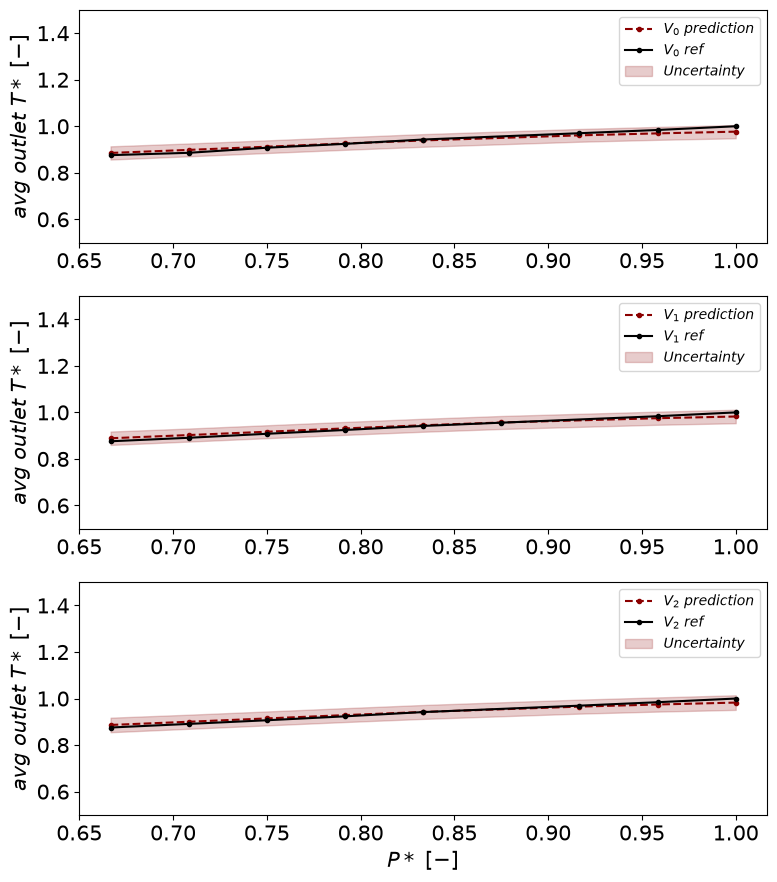

In [12]:
# plot outlet temperature
avg_T_df = pd.DataFrame(avg_outlet_T, columns=['temperature', 'uncertainty', 'Power', 'SlabVelocity'])
avg_T_ref_df = pd.read_csv(os.path.join(path, 'avg_temp.csv'), sep=r"\s+", skipinitialspace=True)
avg_T_ref_df = avg_T_ref_df.iloc[idx_train,:]
avg_T_ref_df = avg_T_ref_df.reset_index()

# auxialiary features of plot
plt.rc('axes', labelsize=15)
plt.rc('xtick', labelsize=15)
plt.rc('ytick', labelsize=15)

fig, axes = plt.subplots(avg_T_ref_df['SlabVelocity'].nunique(), 1, figsize=(8, 9))
# fig.suptitle(r'$\boldsymbol{outlet\ T\ vs. input\ Power}$', fontsize=17)
# fig.supylabel(r'$avg\ outlet\ T*\ [-]$', fontsize=15)

for i, vel in enumerate(avg_T_ref_df['SlabVelocity'].unique()):
    ax = axes[i]
    avg_T = avg_T_df[avg_T_df['SlabVelocity'] == vel]
    avg_T_ref = avg_T_ref_df[avg_T_df['SlabVelocity'] == vel]

    vel = f'V_{{{i}}}'
    Tmax = avg_T_ref['temperature'].max()
    Pmax = avg_T_ref['Power'].max()
    xAxis = avg_T_ref['Power']/Pmax
    # plotting temperature against power
    ax.plot(xAxis, avg_T['temperature']/Tmax, label=rf'${vel}\ prediction$', marker='o', markersize=3, linestyle='--', color='#8B0000')
    ax.plot(xAxis, avg_T_ref['temperature']/Tmax, label=rf'${vel}\ ref$', marker='o', markersize=3, color='black')

    # adding the uncertainties
    ax.fill_between(xAxis, avg_T['temperature']/Tmax - avg_T['uncertainty']/Tmax, avg_T['temperature']/Tmax + avg_T['uncertainty']/Tmax,
                    color='#8B0000', alpha=0.2, label=r'$Uncertainty$')
    
    ax.set_ylabel(r'$avg\ outlet\ T*\ [-]$')
    ax.set_ylim([0.5, 1.5])
    if i == len(avg_T_ref_df['SlabVelocity'].unique()) - 1: ax.set_xlabel(r'$P*\ [-]$')

    ax.legend()

plt.legend()
plt.tight_layout()
plt.show()

***GPR testing:*** \
Testing of the trained GPR model.

In [ ]:
print('\n============================', file=log, flush=True)
print('GPR TESTING', file=log, flush=True)
print('============================', file=log, flush=True)

print('- Predicting POD coefficient(s)... ', file=log, flush=True)
Ap, sigmaP = gpr.predict(P_test) # Ap: POD coefficient, SigmaP: uncertainty (standard deviation) over POD coefficient

# reconstruct the high-dimensional space
print('\n- Moving back to physical space...', file=log, flush=True)
Xp0 = gpr.reconstruct(Ap[:, :gpr.r], modes=gpr.Ur)   # reconstruct only the dimension where POD coefficients are stored
SigmaX0 = gpr.reconstruct(sigmaP[:, :gpr.r], modes=gpr.Ur) # standard deviation

# extract results for chimney species
# Xp0_species = Ap[:,gpr.r:].copy()
# sigmaX0_species = sigmaP[:, gpr.r:].copy()
Xp0_species = gpr.reconstruct(Ap[:, gpr.r:gpr.r+gpr.r_species], modes=gpr.Ur_species)   # reconstruct only the dimension where POD coefficients are stored
SigmaX0_species = gpr.reconstruct(sigmaP[:, gpr.r:gpr.r+gpr.r_species], modes=gpr.Ur_species) # standard deviation

# extract results for flame species
Xp0_flame = gpr.reconstruct(Ap[:, gpr.r+gpr.r_species:gpr.r_t], modes=gpr.Ur_flame)   # reconstruct only the dimension where POD coefficients are stored
SigmaX0_flame = gpr.reconstruct(sigmaP[:, gpr.r+gpr.r_species:gpr.r_t], modes=gpr.Ur_flame) # standard deviation

print('- Data shape: Ap{} sigmaP{} Xp0{} SigmaX0{} Xp0_species{} SigmaX0_species{} Xp0_flame{} SigmaX0_flame{} gpr.r{} gpr.r_species{} gpr.r_flame{} gpr.r_t{}'
      .format(Ap.shape, sigmaP.shape, Xp0.shape, SigmaX0.shape, Xp0_species.shape, SigmaX0_species.shape, 
              Xp0_flame.shape, SigmaX0_flame.shape, gpr.r, gpr.r_species, gpr.r_flame, gpr.r_t), file=log, flush=True)
print('- Data shape: gpr.X_cnt{} gpr.X_cnt_species{} gpr.X_cnt_flame{} \n'.format(gpr.X_cnt.shape, gpr.X_cnt_species.shape, gpr.X_cnt_flame.shape), file=log, flush=True)

# denorm temperature data
Xp = np.empty_like(Xp0)
SigmaX = np.empty_like(SigmaX0)

# denorm uncertainty
SigmaX = SigmaX0 * gpr.X_scl
# denorm prediction
for j in range(n_features):    
    cnt = gpr.X_cnt[j,:] if paramDict['normalization']['axis_cnt'] == 0 else gpr.X_cnt[j*n_cells:(j+1)*n_cells,:]
    Xp[j*n_cells:(j+1)*n_cells,:] = (Xp0[j*n_cells:(j+1)*n_cells,:] * gpr.X_scl[j*n_cells:(j+1)*n_cells]) + cnt

# denorm chimney species data
Xp_species = np.empty_like(Xp0_species)
Xp_species_mean = np.empty((X_species_test.shape[1], n_features_species))
X_species_test_mean = np.empty((X_species_test.shape[1], n_features_species))
sigmaX_species = np.empty_like(SigmaX0_species)
sigmaX_species_mean = np.empty_like(Xp_species_mean)

# denorm uncertainty
sigmaX_species = SigmaX0_species * gpr.X_scl_species
# denorm prediction
for j in range(n_features_species):    
    cnt = gpr.X_cnt_species[j,:] if paramDict['normalization']['axis_cnt'] == 0 else gpr.X_cnt_species[j*n_cells_species:(j+1)*n_cells_species,:]
    Xp_species[j*n_cells_species:(j+1)*n_cells_species,:] = (Xp0_species[j*n_cells_species:(j+1)*n_cells_species,:] * gpr.X_scl_species[j*n_cells_species:(j+1)*n_cells_species]) + cnt
    # building mean tensors
    for i in range(X_species_test.shape[1]):
        Xp_species_mean[i, j] = Xp_species[j*n_cells_species:(j+1)*n_cells_species,i].mean(axis=0).item()
        X_species_test_mean[i, j] = X_species_test[j*n_cells_species:(j+1)*n_cells_species,i].mean(axis=0).item()
        sigmaX_species_mean[i, j] = sigmaX_species[j*n_cells_species:(j+1)*n_cells_species,i].mean(axis=0).item()

# denorm flame temperature & species data # 20260612 D
Xp_flame = np.empty_like(Xp0_flame)
Xp_flame_mean = np.empty((X_flame_test.shape[1], n_features_flame))
X_flame_test_mean = np.empty((X_flame_test.shape[1], n_features_flame))
sigmaX_flame = np.empty_like(SigmaX0_flame)
sigmaX_flame_mean = np.empty_like(Xp_flame_mean)

# denorm uncertainty
sigmaX_flame = SigmaX0_flame * gpr.X_scl_flame
# denorm prediction
for j in range(n_features_flame):    
    cnt = gpr.X_cnt_flame[j,:] if paramDict['normalization']['axis_cnt'] == 0 else gpr.X_cnt_flame[j*n_cells_flame:(j+1)*n_cells_flame,:]
    Xp_flame[j*n_cells_flame:(j+1)*n_cells_flame,:] = (Xp0_flame[j*n_cells_flame:(j+1)*n_cells_flame,:] * gpr.X_scl_flame[j*n_cells_flame:(j+1)*n_cells_flame]) + cnt
    # building mean tensors
    for i in range(X_flame_test.shape[1]):
        Xp_flame_mean[i, j] = Xp_flame[j*n_cells_flame:(j+1)*n_cells_flame,i].mean(axis=0).item()
        X_flame_test_mean[i, j] = X_flame_test[j*n_cells_flame:(j+1)*n_cells_flame,i].mean(axis=0).item()
        sigmaX_flame_mean[i, j] = sigmaX_flame[j*n_cells_flame:(j+1)*n_cells_flame,i].mean(axis=0).item()

# for post-process
for i in range(len(idx_test)):
    print('  * Test case #{}'.format(idx_test[i]), file=log, flush=True)
    for j, feature in enumerate(features):
        print('   -> mean uncertainty of strip outlet {} = {:.3f} % '.format(feature, np.average(np.abs(SigmaX[j*n_cells:(j+1)*n_cells,i]/Xp[j*n_cells:(j+1)*n_cells,i])).item()*100), file=log, flush=True)
    for j, feature in enumerate(features_species):
        print('   -> mean uncertainty of chimney {} = {:.3f} % '.format(feature, np.average(np.abs(sigmaX_species[j*n_cells_species:(j+1)*n_cells_species,i]/Xp_species[j*n_cells_species:(j+1)*n_cells_species,i])).item()*100), file=log, flush=True)
    for j, feature in enumerate(features_flame):
        print('   -> mean uncertainty of flame {} = {:.3f} % '.format(feature, np.average(np.abs(sigmaX_flame[j*n_cells_flame:(j+1)*n_cells_flame,i]/Xp_flame[j*n_cells_flame:(j+1)*n_cells_flame,i])).item()*100), file=log, flush=True)


In [ ]:
# plot results
avg_T_ref_df = pd.read_csv(os.path.join(path, 'avg_temp.csv'), sep=r"\s+", skipinitialspace=True)
avg_T_ref_df = avg_T_ref_df.iloc[idx_test,:]
avg_T_ref_df = avg_T_ref_df.reset_index()
avg_outlet_T = np.empty((len(idx_test), 4))   # to plot outlet temperature

# im_shape_plot = [im_shape[2], im_shape[0]]
feat_idx = 'temperature'   # select the feature to plot
idx = features.index(feat_idx)
idx_flame_temperature = features_flame.index(feat_idx)

# mean evaluation for R2 evaluation
mean = np.empty((n_features,))
mean_species = np.empty((n_features_species,))
mean_flame = np.empty((n_features_flame,))
if paramDict['normalization']['axis_cnt'] == 1:
    for j in range(n_features):
        mean[j] = gpr.X_cnt[j*n_cells:(j+1)*n_cells].mean()
    for j in range(n_features_species):
        mean_species[j] = gpr.X_cnt_species[j*n_cells_species:(j+1)*n_cells_species].mean()
    for j in range(n_features_flame):
        mean_flame[j] = gpr.X_cnt_flame[j*n_cells_flame:(j+1)*n_cells_flame].mean()
else:
    mean = gpr.X_cnt.mean(axis=1)
    mean_species = gpr.X_cnt_species.mean(axis=1)
    mean_flame = gpr.X_cnt_flame.mean(axis=1)

for i in range(len(idx_test)):
    print(' - Plotting results for test case #{} -> {:.2f} MW, strip velocity = {:.2f} m/s'.format(idx_test[i], P_test[i,0], P_test[i,1]))
    print('   i={}, len(idx_test)={}, idx_test(i)={}, idx={}, idx_flame_temperature={}'.format(i, len(idx_test), idx_test[i], idx, idx_flame_temperature))
    X_plot = X_test[idx*n_cells:(idx+1)*n_cells, i]
    Xp_plot = Xp[idx*n_cells:(idx+1)*n_cells, i]
    SigmaX_plot = SigmaX[idx*n_cells:(idx+1)*n_cells, i]

    # evaluation of the errors
    Xplot_torch = torch.from_numpy(X_plot)
    XpPlot_torch = torch.from_numpy(Xp_plot)
    
    norm_error, recon_error, r_square = error_evaluation(Xplot_torch, XpPlot_torch, mean=mean, idx=idx)

    print('  * Average errors (strip outlet temperature): MNSE = {:.3e}, Mean Reconstruction = {:.3e}, Determination coefficient = {:.3f}'.format(norm_error.mean(), recon_error.mean(), r_square.mean()))

    rms_temperature = np.sqrt(np.average((Xp[idx*n_cells:(idx+1)*n_cells,i] - X_test[idx*n_cells:(idx+1)*n_cells,i])**2))
    outlet_T, uncertainty_outlet_T = extract_outlet_temperature([Xp_plot, SigmaX_plot])
    avg_outlet_T[i,:] = np.array([outlet_T, uncertainty_outlet_T, P_test[i,0], P_test[i,1]])

    print('  * Average errors (strip outlet temperature): RMSE = {:.3e}'.format(rms_temperature))
    print('  * Average strip outlet temperature = {:.3f} ± {:.3f} K / {:.3f} K\n'.format(outlet_T, np.abs(uncertainty_outlet_T), avg_T_ref_df.loc[i, 'temperature']))
    
    # saving output
    dfCsv = pd.DataFrame(Xp_plot, columns=['temperature'])
    df = pd.concat([coord, dfCsv], axis=1)
    df = df.reset_index(drop=True)
    savePath = os.path.join(path, 'plane-xz-strip-middle_outlet', 'test_results')
    os.makedirs(savePath, exist_ok=True)
    df.to_csv(os.path.join(savePath, f'case_{P_test[i,1]}ms_{P_test[i,0]}MW.csv'), sep='\t', index=False)

    # plot_comparison([X_plot, Xp_plot], feat_idx, im_shape_plot, i, cmap='inferno', train=False, show_fig=True)
    
    # chimney temperature & species
    for j, var in enumerate(features_species):
        X_species_plot = X_species_test[j*n_cells_species:(j+1)*n_cells_species, i]
        Xp_species_plot = Xp_species[j*n_cells_species:(j+1)*n_cells_species, i]
        sigmaX_species_plot = sigmaX_species[j*n_cells_species:(j+1)*n_cells_species, i]

        # evaluation of the errors
        Xplot_species_torch = torch.from_numpy(X_species_plot)
        XpPlot_species_torch = torch.from_numpy(Xp_species_plot)

        norm_error_species, recon_error_species, r_square_species = error_evaluation(Xplot_species_torch, XpPlot_species_torch, mean=mean_species, idx=j)
        rms_species = np.sqrt(np.average((Xp_species[j*n_cells_species:(j+1)*n_cells_species,i] - X_species_test[j*n_cells_species:(j+1)*n_cells_species,i])**2))
        print('  * Average errors (chimney species): {} -> MNSE = {:.3e}, Mean Reconstruction = {:.3e}, Determination coefficient = {:.3f}'.format(var, norm_error_species.mean(), recon_error_species.mean(), r_square_species.mean()))
        print('  * Average errors (chimney species): {} -> RMSE = {:.3e}'.format(var, rms_species))
        # print('  * Average outlet {} = {:.5e} ± {:.5e}'.format(var, Xp_species[i, j], sigmaX_species[i, j]))
        print('  * Average outlet (chimney species): {} = {:.5f} ± {:.5f} / {:.5f}'.format(var, Xp_species_mean[i, j], np.abs(sigmaX_species_mean[i, j]), X_species_test_mean[i, j]))
    print('  ')

    # flame temperature & species
    for j, var in enumerate(features_flame):
        X_flame_plot = X_flame_test[j*n_cells_flame:(j+1)*n_cells_flame, i]
        Xp_flame_plot = Xp_flame[j*n_cells_flame:(j+1)*n_cells_flame, i]
        sigmaX_flame_plot = sigmaX_flame[j*n_cells_flame:(j+1)*n_cells_flame, i]

        # evaluation of the errors
        Xplot_flame_torch = torch.from_numpy(X_flame_plot)
        XpPlot_flame_torch = torch.from_numpy(Xp_flame_plot)

        norm_error_flame, recon_error_flame, r_square_flame = error_evaluation(Xplot_flame_torch, XpPlot_flame_torch, mean=mean_flame, idx=j)
        rms_flame = np.sqrt(np.average((Xp_flame[j*n_cells_flame:(j+1)*n_cells_flame,i] - X_flame_test[j*n_cells_flame:(j+1)*n_cells_flame,i])**2))
        
        print('  * Average errors (flame species): {} -> MNSE = {:.3e}, Mean Reconstruction = {:.3e}, Determination coefficient = {:.3f}'.format(var, norm_error_flame.mean(), recon_error_flame.mean(), r_square_flame.mean()))
        print('  * Average errors (flame species): {} -> RMSE = {:.3e}'.format(var, rms_flame))
        print('  * Average outlet (flame species): {} = {:.5f} ± {:.5f} / {:.5f}'.format(var, Xp_flame_mean[i, j], np.abs(sigmaX_flame_mean[i, j]), X_flame_test_mean[i, j]))
    print('  -----------\n')

    # saving output : flame temperature & species
    X_flame_plot = X_flame_test[idx_flame_temperature*n_cells_flame:(idx_flame_temperature+1)*n_cells_flame, i]
    dfCsv = pd.DataFrame(X_flame_plot, columns=['temperature'])
    df = pd.concat([coord_flame, dfCsv], axis=1)
    df = df.reset_index(drop=True)
    savePath = os.path.join(path, 'plane-xz-strip-middle_outlet', 'test_results')
    os.makedirs(savePath, exist_ok=True)
    df.to_csv(os.path.join(savePath, f'brbot_case_{P_test[i,1]}ms_{P_test[i,0]}MW_speciesT_FLUENTtest.csv'), sep='\t', index=False)

    # saving FLUENT CFD input for reading in Paraview: flame temperature & species
    Xp_flame_plot = Xp_flame[idx_flame_temperature*n_cells_flame:(idx_flame_temperature+1)*n_cells_flame, i]
    dfCsv = pd.DataFrame(Xp_flame_plot, columns=['temperature'])
    df = pd.concat([coord_flame, dfCsv], axis=1)
    df = df.reset_index(drop=True)
    savePath = os.path.join(path, 'plane-xz-strip-middle_outlet', 'test_results')
    os.makedirs(savePath, exist_ok=True)
    df.to_csv(os.path.join(savePath, f'brbot_case_{P_test[i,1]}ms_{P_test[i,0]}MW_speciesT_ROMtest.csv'), sep='\t', index=False)

 - Plotting results for test case #5 -> 7.35 MW, strip velocity = 0.36 m/s
   i=0, len(idx_test)=3, idx_test(i)=5, idx=0, idx_flame_temperature=0
  * Average errors (strip outlet temperature): MNSE = 2.485e-05, Mean Reconstruction = 5.426e-06, Determination coefficient = 1.000
  * Average errors (strip outlet temperature): RMSE = 2.658e+00
  * Average strip outlet temperature = 850.268 ± 24.413 K / 855.100 K

  * Average errors (chimney species): temperature -> MNSE = 4.664e-04, Mean Reconstruction = 1.884e-03, Determination coefficient = 0.769
  * Average errors (chimney species): temperature -> RMSE = 1.976e+01
  * Average outlet (chimney species): temperature = 914.87272 ± 3.80772 / 914.29166
  * Average errors (chimney species): o2 -> MNSE = 1.848e-05, Mean Reconstruction = 3.676e-04, Determination coefficient = 0.669
  * Average errors (chimney species): o2 -> RMSE = 1.251e-04
  * Average outlet (chimney species): o2 = 0.02919 ± 0.00013 / 0.02909
  * Average errors (chimney specie

 - Plotting results for test case #5 -> 7.35 MW, strip velocity = 0.36 m/s
 - Plotting results for test case #15 -> 7.70 MW, strip velocity = 0.40 m/s
 - Plotting results for test case #23 -> 7.35 MW, strip velocity = 0.44 m/s


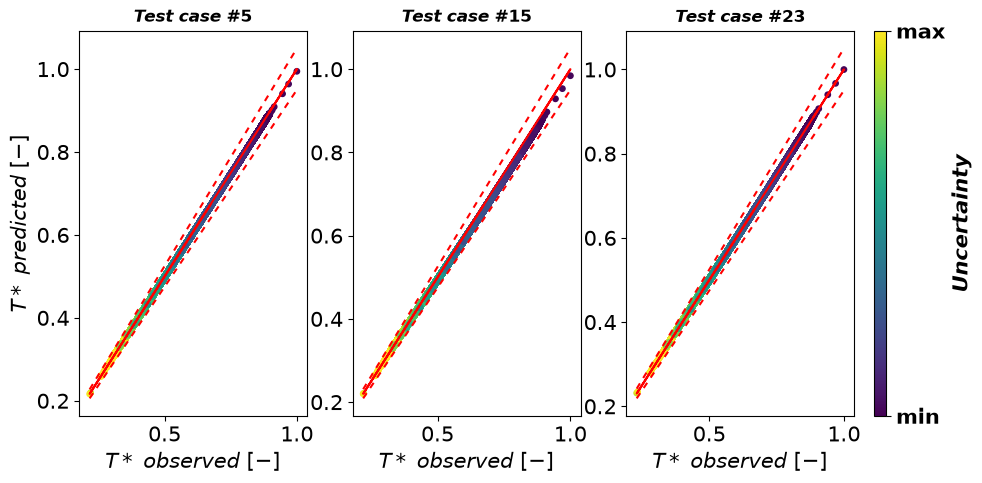

In [15]:
# parity plot
# auxialiary features of plot
plt.rc('axes', labelsize=15)
plt.rc('xtick', labelsize=15)
plt.rc('ytick', labelsize=15)

fig, axes = plt.subplots(ncols=len(idx_test), figsize=(10,5))
# fig.suptitle(r'$\boldsymbol{Parity\ plot\ for\ T\ prediction}$', fontsize=17)
# fig.supxlabel(r'$T*\ observed\ [-]$', fontsize=15)

for i in range(len(idx_test)):
    print(' - Plotting results for test case #{} -> {:.2f} MW, strip velocity = {:.2f} m/s'.format(idx_test[i], P_test[i,0], P_test[i,1]))

    X_plot = X_test[idx*n_cells:(idx+1)*n_cells, i]
    Xp_plot = Xp[idx*n_cells:(idx+1)*n_cells, i]
    SigmaX_plot = SigmaX[idx*n_cells:(idx+1)*n_cells, i]
    
    Tmax = X_plot.max()
    
    ax = axes[i]
    ax.scatter(X_plot/Tmax, Xp_plot/Tmax, marker='o', c=SigmaX_plot/Tmax, cmap='viridis', s=15)
    ax.plot(X_plot/Tmax, X_plot/Tmax, color='red')
    
    # error band
    num = int(((X_plot/Tmax).max() - (X_plot/Tmax).min()) // 0.05)
    xaxis = np.linspace((X_plot/Tmax).min(), (X_plot/Tmax).max(), num=num)
    # neg_error = (X_plot/Tmax - (X_plot/Tmax)*0.1)
    # pos_error = (X_plot/Tmax + (X_plot/Tmax)*0.1)
    neg_error = (xaxis - (xaxis)*0.05)
    pos_error = (xaxis + (xaxis)*0.05)
    ax.plot(xaxis, neg_error, color='red', linestyle=(0, (3, 3)))
    ax.plot(xaxis, pos_error, color='red', linestyle=(0, (3, 3)))

    if i == 0: ax.set_ylabel(r'$T*\ predicted\ [-]$')
    ax.set_xlabel(r'$T*\ observed\ [-]$')
    ax.set_title(rf'$\boldsymbol{{Test\ case\ \#{idx_test[i]}}}$')

    # ax.set_aspect('equal')
    
    if i == len(idx_test) - 1:    
        ax_bounds = ax.get_position().bounds
        vmin = (SigmaX_plot/Tmax).min()
        vmax = (SigmaX_plot/Tmax).max()
        cb_ax = fig.add_axes([0.92, ax_bounds[1], 0.012, ax_bounds[3]])
        norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
        cbar = fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap='viridis'), 
                            cax=cb_ax, orientation='vertical')
        
        cbar.set_label(r'$\boldsymbol{Uncertainty}$', fontsize=15)

        cbar.set_ticks([vmin, vmax])
        cbar.set_ticklabels([r'$\mathbf{min}$', r'$\mathbf{max}$'], fontsize=15)


# plt.tight_layout()
plt.show()

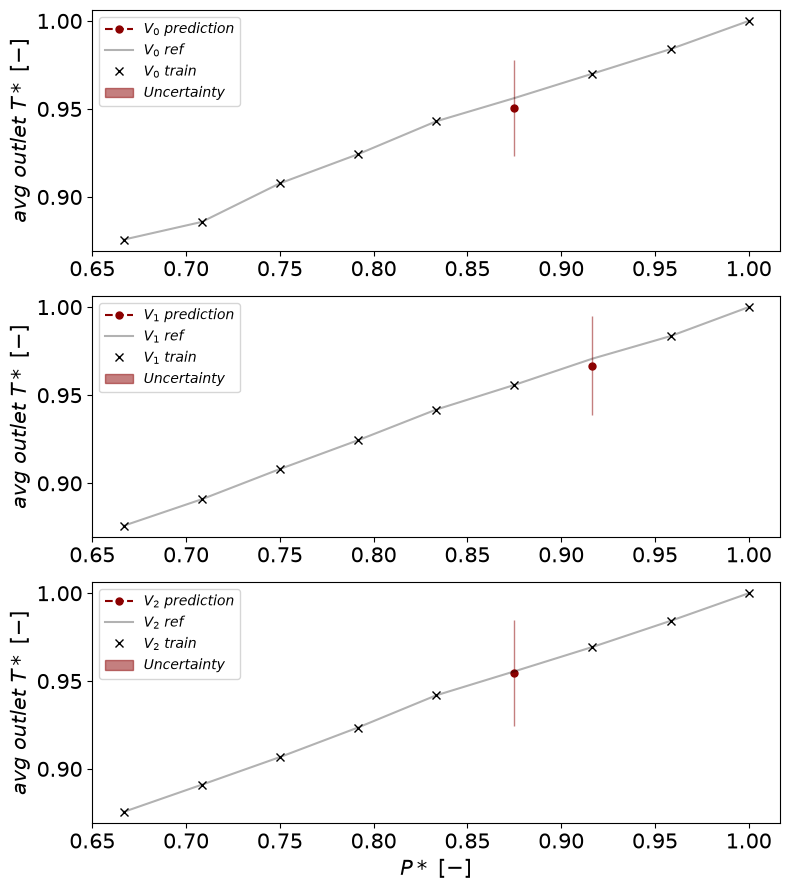

In [16]:
# plot strip outlet temperature
avg_T_df = pd.DataFrame(avg_outlet_T, columns=['temperature', 'uncertainty', 'Power', 'SlabVelocity'])
avg_T_ref_df = pd.read_csv(os.path.join(path, 'avg_temp.csv'), sep=r"\s+", skipinitialspace=True)
avg_T_ref_train_df = avg_T_ref_df.iloc[idx_train,:]
avg_T_ref_train_df = avg_T_ref_train_df.reset_index()

# auxialiary features of plot
plt.rc('axes', labelsize=15)
plt.rc('xtick', labelsize=15)
plt.rc('ytick', labelsize=15)

fig, axes = plt.subplots(avg_T_ref_df['SlabVelocity'].nunique(), 1, figsize=(8, 9))
# fig.suptitle(r'$\boldsymbol{outlet\ T\ vs. input\ Power}$', fontsize=17)
# fig.supylabel(r'$avg\ outlet\ T*\ [-]$', fontsize=15)

for i, vel in enumerate(avg_T_ref_df['SlabVelocity'].unique()):
    ax = axes[i]
    avg_T = avg_T_df[avg_T_df['SlabVelocity'] == vel]
    avg_T_ref = avg_T_ref_df[avg_T_ref_df['SlabVelocity'] == vel]
    avg_T_ref_train = avg_T_ref_train_df[avg_T_ref_train_df['SlabVelocity'] == vel]

    vel = f'V_{{{i}}}'
    Tmax = avg_T_ref['temperature'].max()
    Pmax = avg_T_ref['Power'].max()
    xAxis = avg_T_ref['Power']/Pmax
    xAxis_test = avg_T['Power']/Pmax
    xAxis_train = avg_T_ref_train['Power']/Pmax

    # plotting temperature against power
    ax.plot(xAxis_test, avg_T['temperature']/Tmax, label=rf'${vel}\ prediction$', marker='o', markersize=5, linestyle='--', color='#8B0000')
    ax.plot(xAxis, avg_T_ref['temperature']/Tmax, label=rf'${vel}\ ref$', color='black', alpha=0.3)
    ax.plot(xAxis_train, avg_T_ref_train['temperature']/Tmax, label=rf'${vel}\ train$', marker='x', linestyle='', color='black')

    # adding the uncertainties
    ax.fill_between(xAxis_test, avg_T['temperature']/Tmax - avg_T['uncertainty']/Tmax, avg_T['temperature']/Tmax + avg_T['uncertainty']/Tmax,
                    color='#8B0000', alpha=0.5, label=r'$Uncertainty$')
    
    ax.set_ylabel(r'$avg\ outlet\ T*\ [-]$')
    # ax.set_ylim([0.5, 1.5])
    if i == len(avg_T_ref_df['SlabVelocity'].unique()) - 1: ax.set_xlabel(r'$P*\ [-]$')

    ax.legend()

plt.legend()
plt.tight_layout()
plt.show()

***Control loop implementation***

Example of how to use the DT for updating the state of the furnace:

In [ ]:
class PController:

    def __init__(self,
                 Kp,
                 setpoint,
                 output_limits=(None, None)):

        self.Kp = Kp
        self.setpoint = setpoint

        self.min_output, self.max_output = output_limits

    def update(self, measurement, sigma, op_cond, gpr, sigma_lim=None):

        # Control error
        error = self.setpoint - measurement

        # Proportional action
        if self.Kp is None:
            # local secant/Newton estimate of dT/dPower instead of a fixed gain
            dP = max(0.05, 0.02 * op_cond[0])
            T_plus, _ = prediction_outlet_T(gpr, np.array([op_cond[0]+dP, op_cond[1]]))
            slope = (T_plus - measurement) / dP
            output = error / slope if abs(slope) > 1e-6 else 0.0
        else:
            output = self.Kp * error

        # damp the step and clip if the ROM is extrapolating (sigma large)
        alpha = 0.1
        if sigma_lim is not None and sigma > sigma_lim:
            alpha = 0.01
            
        output = np.clip(output * alpha, self.min_output, self.max_output)
        
        # Saturation
        if self.min_output is not None:
            output = max(self.min_output, output)

        if self.max_output is not None:
            output = min(self.max_output, output)

        return output

def prediction_outlet_T(gpr, P_control):
    Ap, sigmaP = gpr.predict(P_control)   # Ap: POD coefficient, SigmaP: uncertainty (standard deviation) over POD coefficient

    # reconstruct the high-dimensional space
    print('\n- Moving back to physical space...', file=log, flush=True)
    Xp0 = gpr.reconstruct(Ap[:, :gpr.r], modes=gpr.Ur)   # reconstruct only the dimension where POD coefficients are stored
    SigmaX0 = gpr.reconstruct(sigmaP[:, :gpr.r], modes=gpr.Ur) # standard deviation

    # denorm temperature data
    Xp = np.empty_like(Xp0)
    SigmaX = np.empty_like(SigmaX0)

    # denorm uncertainty
    SigmaX = SigmaX0 * gpr.X_scl

    # denorm prediction
    for j in range(n_features):    
        cnt = gpr.X_cnt[j,:] if paramDict['normalization']['axis_cnt'] == 0 else gpr.X_cnt[j*n_cells:(j+1)*n_cells,:]
        Xp[j*n_cells:(j+1)*n_cells,:] = (Xp0[j*n_cells:(j+1)*n_cells,:] * gpr.X_scl[j*n_cells:(j+1)*n_cells]) + cnt

    # Compute the controlled quantity
    outlet_T, uncertainty_outlet_T = extract_outlet_temperature([Xp, SigmaX])

    return outlet_T, uncertainty_outlet_T
    

In [18]:
setpoint = 750   # establish desired temperature at the outlet
power_controller = PController(
    Kp=None,
    setpoint=setpoint,
    output_limits=(-0.05, 0.05)   # set limit for inlet velocity increment
)

velocity_controller = PController(
    Kp=None,
    setpoint=setpoint,
    output_limits=(-0.05, 0.05)   # set limit for inlet velocity increment
)

In [ ]:
# introduce the control loop sequence
max_iter = 100
tol = 1  # temperature tollerance
power = 8.05
velocity = 0.41
# P_control = np.array([velocity, power])
P_control = np.array([power, velocity])
history = []

# for post-processing
vMax = avg_T_ref_df['SlabVelocity'].max()
TMax = avg_T_ref_df['temperature'].max()
PMax = avg_T_ref_df['Power'].max()

for k in range(max_iter):

    outlet_T, uncertainty_outlet_T = prediction_outlet_T(gpr, P_control)

    print(f"Iteration {k}: outlet Temperature = {outlet_T:.2f} K")

    history.append({'iter': k, 'power': power/PMax, 'velocity': velocity/vMax, 'T_pred': outlet_T.item()/TMax,
                    'sigma': np.abs(uncertainty_outlet_T/TMax).item(), 'error': (setpoint-outlet_T).item() , 'status': 'ok'})
    
    # break if below the tollerance
    if abs(setpoint-outlet_T) < tol:
        break

    # Compute control action
    delta_power = power_controller.update(outlet_T, uncertainty_outlet_T, P_control, gpr, sigma_lim=20)

    # Update boundary condition
    power += delta_power

    # Enforce physical limits
    power = np.clip(power, 5.60, 8.40)
    P_control = np.array([power, velocity])


Iteration 0: outlet Temperature = 820.33 K
Iteration 1: outlet Temperature = 819.38 K
Iteration 2: outlet Temperature = 818.41 K
Iteration 3: outlet Temperature = 817.42 K
Iteration 4: outlet Temperature = 816.41 K
Iteration 5: outlet Temperature = 815.37 K
Iteration 6: outlet Temperature = 814.31 K
Iteration 7: outlet Temperature = 813.22 K
Iteration 8: outlet Temperature = 812.10 K
Iteration 9: outlet Temperature = 810.95 K
Iteration 10: outlet Temperature = 809.76 K
Iteration 11: outlet Temperature = 808.55 K
Iteration 12: outlet Temperature = 807.30 K
Iteration 13: outlet Temperature = 806.02 K
Iteration 14: outlet Temperature = 804.71 K
Iteration 15: outlet Temperature = 803.36 K
Iteration 16: outlet Temperature = 801.98 K
Iteration 17: outlet Temperature = 800.57 K
Iteration 18: outlet Temperature = 799.13 K
Iteration 19: outlet Temperature = 797.66 K
Iteration 20: outlet Temperature = 796.16 K
Iteration 21: outlet Temperature = 794.63 K
Iteration 22: outlet Temperature = 793.07 

In [20]:
power_list = []
temp_list = []
uncertain_list = []
setpoint /= TMax
for i in range(len(history)):
    power_list.append(history[i]['power'].item())
    temp_list.append(history[i]['T_pred'].item())
    uncertain_list.append(history[i]['sigma'])

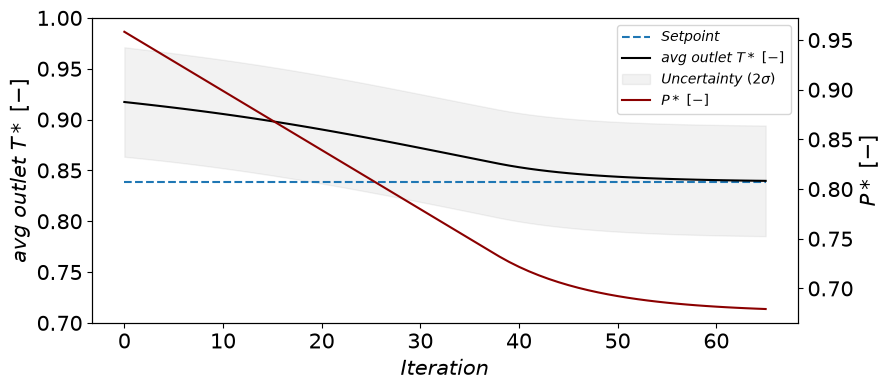

In [ ]:
# plot results
fig, ax1 = plt.subplots(1, 1, figsize=(9, 4))
xAxis = np.arange(len(power_list))

ax1.hlines(setpoint, xAxis[0], xAxis[-1], linestyles='--', label=r'$Setpoint$')
ax1.plot(xAxis, temp_list, label=r'$avg\ outlet\ T*\ [-]$', color='black')
ax1.set_xlabel(r'$Iteration$')
ax1.set_ylabel(r'$avg\ outlet\ T*\ [-]$', color='black')
ax1.tick_params(axis='y', labelcolor='black')
ax1.fill_between(xAxis, np.array(temp_list) - 2 * np.array(uncertain_list), np.array(temp_list) + 2 * np.array(uncertain_list),
                    color="#000000", alpha=0.05, label=r'$Uncertainty\ (2\sigma)$')
ax1.set_ylim([0.7, 1])

# right axis: power
ax2 = ax1.twinx()
ax2.plot(xAxis, power_list, label=r'$P*\ [-]$', color='#8B0000')
ax2.set_ylabel(r'$P*\ [-]$')

# merge legends from both axes into one
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')

plt.tight_layout()
plt.show()
